# Bike Sharing Demand Prediction
### Created By : [Nama Anda]

## Business Problem Understanding

**Context**  
Bike sharing adalah sistem penyewaan sepeda otomatis yang memungkinkan pengguna untuk menyewa dan mengembalikan sepeda di stasiun yang berbeda. Sistem ini telah menjadi solusi transportasi perkotaan yang semakin populer karena ramah lingkungan dan efisien.

Dalam dataset ini terdapat dua jenis pengguna:
- **Casual users** : pengguna yang tidak terdaftar/berlangganan
- **Registered users** : pengguna yang sudah terdaftar/berlangganan

Kedua jenis pengguna ini memiliki pola penggunaan yang berbeda secara fundamental, sehingga perlu dimodelkan secara terpisah.

**Problem Statement :**

Perusahaan bike sharing menghadapi tantangan dalam mengelola ketersediaan sepeda di setiap stasiun. Tanpa prediksi permintaan yang akurat, sering terjadi:
- **Oversupply** : terlalu banyak sepeda di lokasi sepi → biaya redistribusi dan parkir tinggi
- **Undersupply** : kekurangan sepeda di lokasi ramai → pelanggan kecewa dan beralih ke transportasi lain

**Goals :**

Berdasarkan permasalahan tersebut, tujuan dari proyek ini adalah:
1. Membangun model machine learning untuk **memprediksi jumlah pengguna casual per jam**
2. Membangun model machine learning untuk **memprediksi jumlah pengguna registered per jam**

Dengan model prediksi ini, perusahaan dapat merencanakan distribusi sepeda secara proaktif dan efisien.

**Analytic Approach :**

Yang akan kita lakukan adalah:
1. Menganalisis data untuk menemukan pola permintaan berdasarkan waktu, cuaca, dan musim
2. Membangun dan membandingkan beberapa model regresi
3. Melakukan hyperparameter tuning pada model terbaik
4. Menganalisis feature importance untuk memahami faktor-faktor penggerak permintaan

**Metric Evaluation**

Karena ini adalah masalah **regresi** (memprediksi nilai numerik kontinu), metrik yang digunakan:

- **RMSE (Root Mean Squared Error)** — metrik utama. Memberikan penalti lebih besar untuk error besar, penting untuk operasional karena misprediksi ekstrem sangat merugikan.

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

- **MAE (Mean Absolute Error)** — rata-rata selisih absolut, lebih mudah diinterpretasikan secara bisnis (rata-rata salah sekian unit per jam).

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

- **R² (R-squared)** — proporsi variasi data yang bisa dijelaskan model. Semakin mendekati 1.0, semakin baik.

Model terbaik → **RMSE terkecil** + **R² tertinggi**.

## Data Understanding

Dataset yang digunakan adalah **Bike Sharing Dataset** yang berisi data penyewaan sepeda per jam. Dataset merekam informasi kondisi cuaca, waktu, dan jumlah pengguna di setiap jam.

### Attribute Information

| Attribute | Tipe Data | Deskripsi |
| --- | --- | --- |
| dteday | Object | Tanggal pencatatan |
| season | Integer | Musim (1: Winter, 2: Spring, 3: Summer, 4: Fall) |
| hr | Integer | Jam dalam sehari (0–23) |
| holiday | Integer | Hari libur nasional atau tidak (0/1) |
| temp | Float | Temperatur ternormalisasi dalam Celsius |
| atemp | Float | Temperatur perasaan ternormalisasi dalam Celsius |
| hum | Float | Kelembaban ternormalisasi |
| weathersit | Integer | Kondisi cuaca (1: Cerah, 2: Berkabut, 3: Hujan Ringan, 4: Hujan Lebat) |
| casual | Integer | Jumlah pengguna casual (tidak terdaftar) — **Target 1** |
| registered | Integer | Jumlah pengguna registered (terdaftar) — **Target 2** |
| cnt | Integer | Total penyewaan = casual + registered |

In [1]:
# ── Library Utama ──────────────────────────────────────────
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Preprocessing & Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Model Selection
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import lightgbm as lgb

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [2]:
# Load Dataset
df = pd.read_csv('data_bike_sharing.csv')
df.head()

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857


In [3]:
print(f"Shape dataset: {df.shape}")
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

Shape dataset: (12165, 11)
Jumlah baris : 12165
Jumlah kolom : 11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      12165 non-null  object 
 1   hum         12165 non-null  float64
 2   weathersit  12165 non-null  int64  
 3   holiday     12165 non-null  int64  
 4   season      12165 non-null  int64  
 5   atemp       12165 non-null  float64
 6   temp        12165 non-null  float64
 7   hr          12165 non-null  int64  
 8   casual      12165 non-null  int64  
 9   registered  12165 non-null  int64  
 10  cnt         12165 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 1.0+ MB


In [5]:
df.describe()

,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
count,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000
mean,0.625451,1.416934,0.029758,2.488615,0.476996,0.498185,11.519770,35.834443,153.436580,189.271023
std,0.192102,0.635937,0.169925,1.106157,0.171857,0.192492,6.931872,49.489286,151.046123,181.223903
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,0.470000,1.000000,0.000000,2.000000,0.333300,0.340000,6.000000,4.000000,34.000000,40.000000
50%,0.620000,1.000000,0.000000,2.000000,0.484800,0.500000,12.000000,17.000000,115.000000,142.000000
75%,0.780000,2.000000,0.000000,3.000000,0.621200,0.660000,18.000000,49.000000,220.000000,282.000000
max,1.000000,4.000000,1.000000,4.000000,1.000000,1.000000,23.000000,362.000000,876.000000,970.000000


In [6]:
# Cek Missing Values
print("Missing Values per Kolom:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values per Kolom:
dteday        0
hum           0
weathersit    0
holiday       0
season        0
atemp         0
temp          0
hr            0
casual        0
registered    0
cnt           0
dtype: int64

Total missing values: 0


In [7]:
# Cek Duplikat
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 0


Dataset dalam kondisi bersih — tidak ada missing values maupun baris duplikat. Kita bisa langsung lanjut ke EDA.

## Exploratory Data Analysis

### 1. Distribusi Target Variable

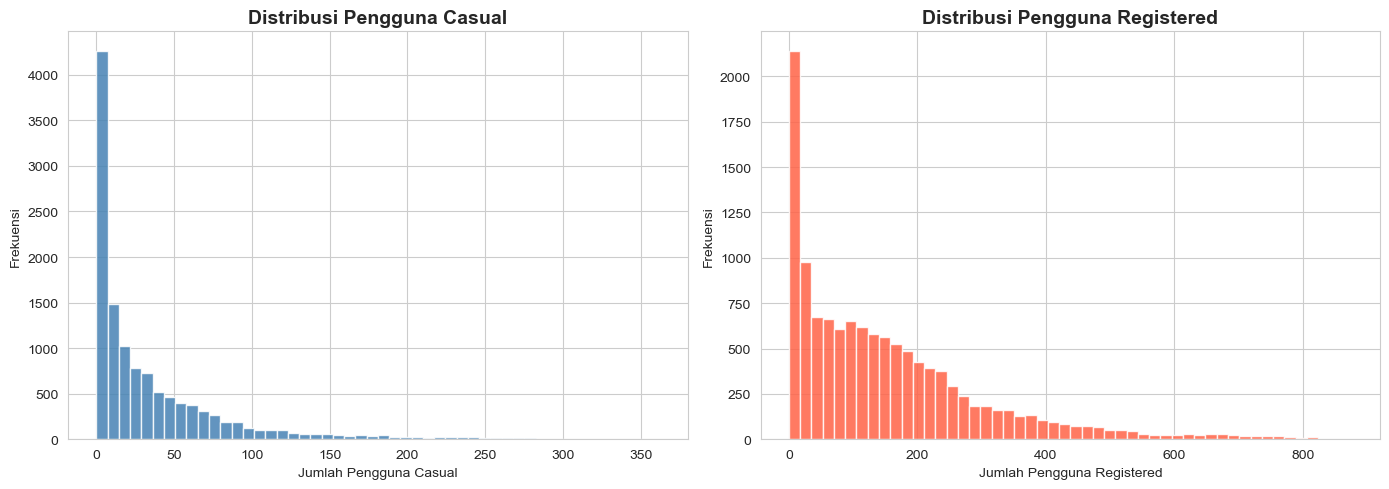

Casual     — Mean: 35.8, Median: 17.0, Max: 362, Skewness: 2.48
Registered — Mean: 153.4, Median: 115.0, Max: 876, Skewness: 1.55


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['casual'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Pengguna Casual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Pengguna Casual')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df['registered'], bins=50, color='tomato', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Pengguna Registered', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Pengguna Registered')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f"Casual     — Mean: {df['casual'].mean():.1f}, Median: {df['casual'].median():.1f}, Max: {df['casual'].max()}, Skewness: {df['casual'].skew():.2f}")
print(f"Registered — Mean: {df['registered'].mean():.1f}, Median: {df['registered'].median():.1f}, Max: {df['registered'].max()}, Skewness: {df['registered'].skew():.2f}")

Distribusi kedua target bersifat **right-skewed** (positif). Sebagian besar jam memiliki jumlah pengguna yang rendah, namun ada jam-jam tertentu dengan permintaan sangat tinggi. Pengguna `registered` memiliki rata-rata dan nilai maksimum yang jauh lebih besar dibanding `casual`.

### 2. Pola Penggunaan per Jam (Hourly Pattern)

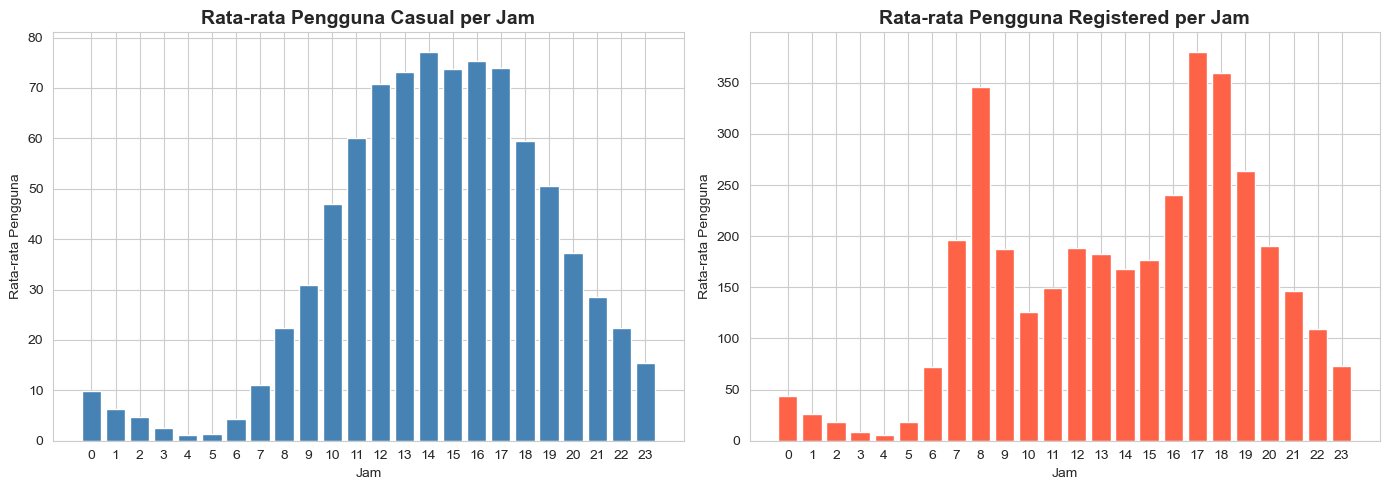

In [9]:
hourly_casual = df.groupby('hr')['casual'].mean()
hourly_registered = df.groupby('hr')['registered'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_casual.index, hourly_casual.values, color='steelblue', edgecolor='white')
axes[0].set_title('Rata-rata Pengguna Casual per Jam', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Rata-rata Pengguna')
axes[0].set_xticks(range(0, 24))

axes[1].bar(hourly_registered.index, hourly_registered.values, color='tomato', edgecolor='white')
axes[1].set_title('Rata-rata Pengguna Registered per Jam', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Rata-rata Pengguna')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

Perbedaan pola yang sangat jelas antara dua segmen:
- **Casual users**: puncak penggunaan di siang hari (12:00–15:00) → pola **rekreasi**
- **Registered users**: puncak di jam sibuk pagi (08:00) dan sore (17:00–18:00) → pola **komuter**

Ini menjadi justifikasi kuat untuk pemodelan terpisah.

### 3. Penggunaan per Musim

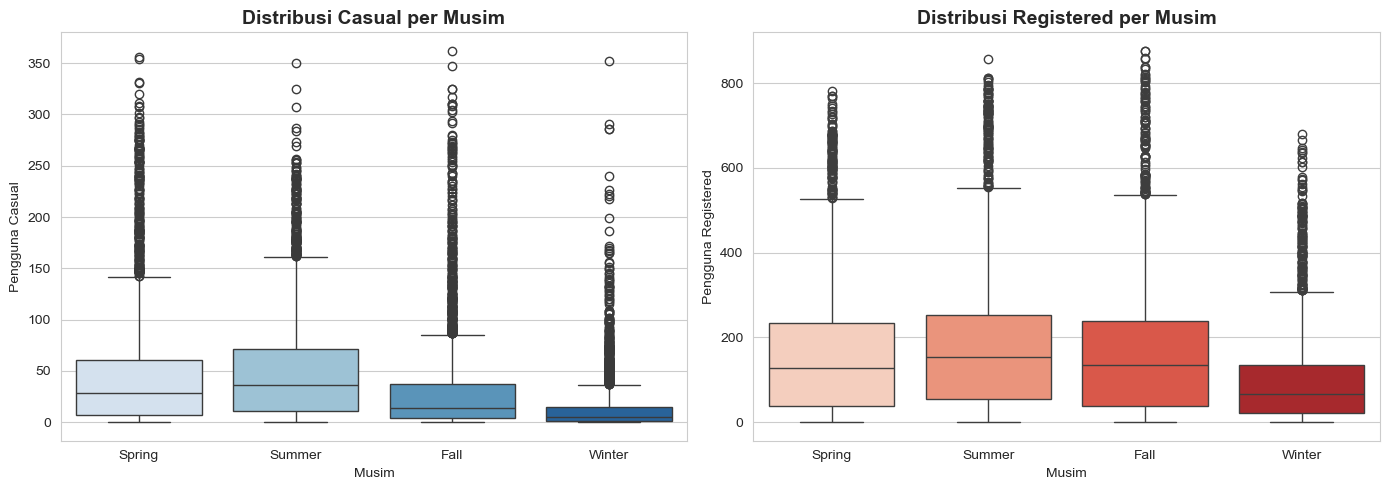

In [10]:
season_labels = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
df['season_label'] = df['season'].map(season_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='season_label', y='casual',
            order=['Spring', 'Summer', 'Fall', 'Winter'],
            palette='Blues', ax=axes[0])
axes[0].set_title('Distribusi Casual per Musim', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Pengguna Casual')

sns.boxplot(data=df, x='season_label', y='registered',
            order=['Spring', 'Summer', 'Fall', 'Winter'],
            palette='Reds', ax=axes[1])
axes[1].set_title('Distribusi Registered per Musim', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Musim')
axes[1].set_ylabel('Pengguna Registered')

plt.tight_layout()
plt.show()

Musim **Summer** dan **Fall** memiliki permintaan lebih tinggi dibanding **Winter**. Pengguna casual menunjukkan sensitivitas musim yang lebih besar — wajar karena aktivitas rekreasi sangat dipengaruhi cuaca.

### 4. Pengaruh Kondisi Cuaca

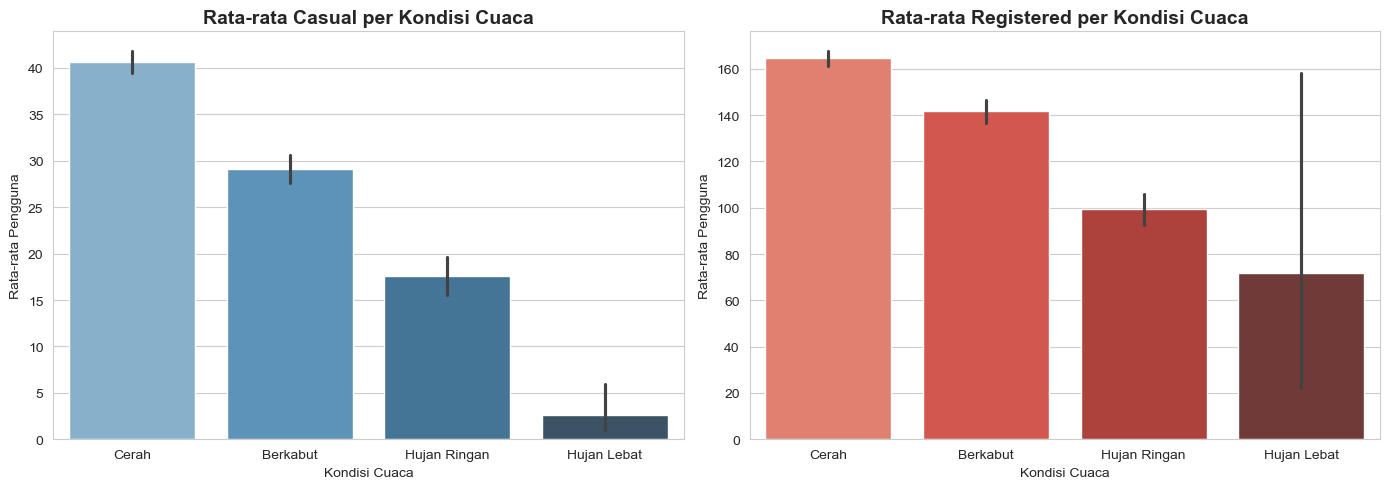

In [11]:
weather_labels = {1: 'Cerah', 2: 'Berkabut', 3: 'Hujan Ringan', 4: 'Hujan Lebat'}
df['weather_label'] = df['weathersit'].map(weather_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='weather_label', y='casual',
            order=['Cerah', 'Berkabut', 'Hujan Ringan', 'Hujan Lebat'],
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Rata-rata Casual per Kondisi Cuaca', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kondisi Cuaca')
axes[0].set_ylabel('Rata-rata Pengguna')

sns.barplot(data=df, x='weather_label', y='registered',
            order=['Cerah', 'Berkabut', 'Hujan Ringan', 'Hujan Lebat'],
            palette='Reds_d', ax=axes[1])
axes[1].set_title('Rata-rata Registered per Kondisi Cuaca', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Pengguna')

plt.tight_layout()
plt.show()

Cuaca buruk menurunkan permintaan secara signifikan, terutama untuk casual users. Registered users lebih 'tahan' cuaca buruk — kemungkinan karena mereka sudah berkomitmen menggunakan sepeda sebagai alat transportasi utama.

### 5. Pengaruh Suhu terhadap Permintaan

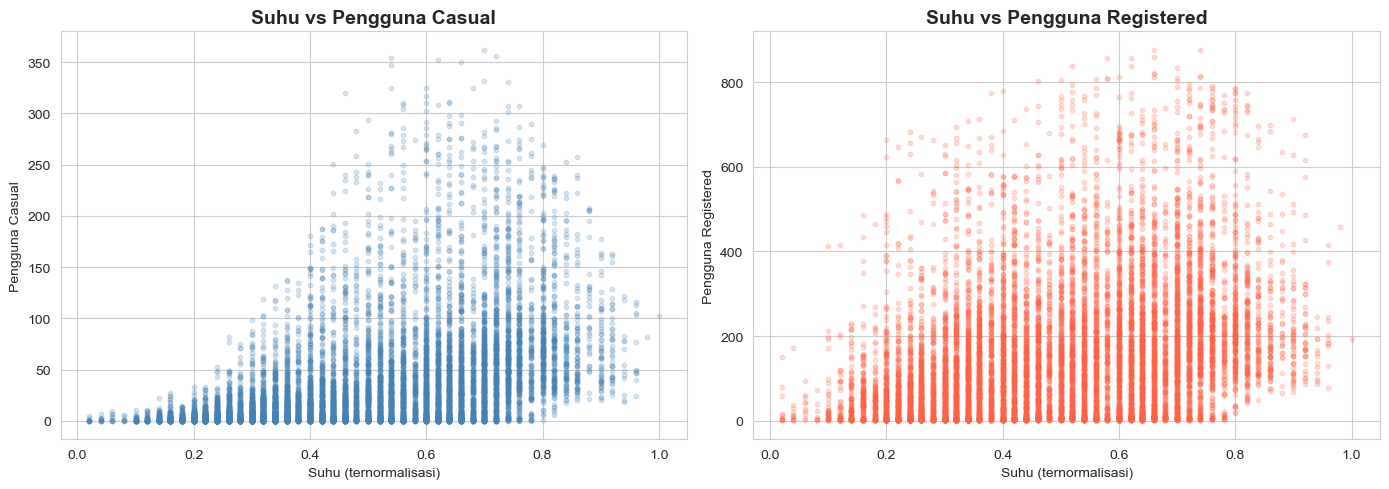

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['temp'], df['casual'], alpha=0.2, color='steelblue', s=10)
axes[0].set_title('Suhu vs Pengguna Casual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Suhu (ternormalisasi)')
axes[0].set_ylabel('Pengguna Casual')

axes[1].scatter(df['temp'], df['registered'], alpha=0.2, color='tomato', s=10)
axes[1].set_title('Suhu vs Pengguna Registered', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Suhu (ternormalisasi)')
axes[1].set_ylabel('Pengguna Registered')

plt.tight_layout()
plt.show()

### 6. Heatmap Korelasi

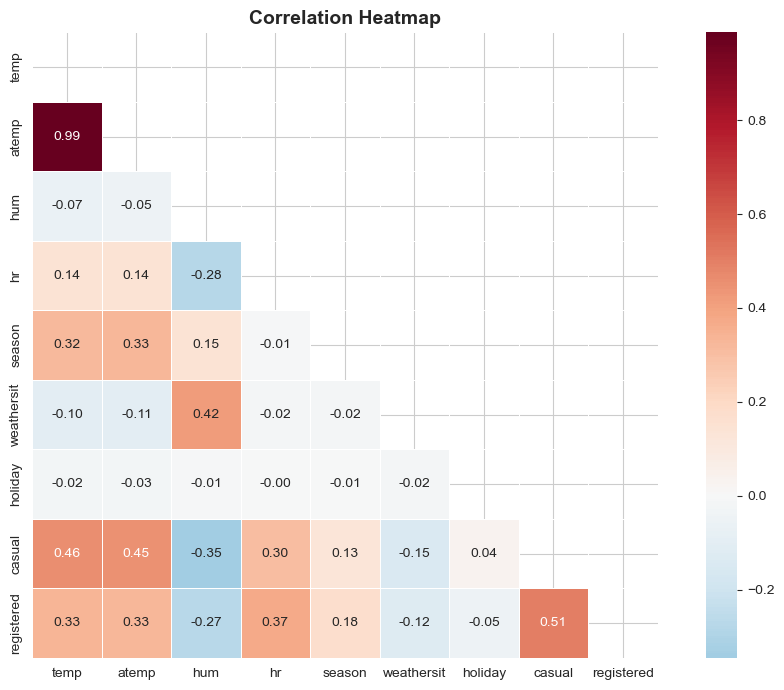

In [13]:
plt.figure(figsize=(10, 7))
numeric_cols = ['temp', 'atemp', 'hum', 'hr', 'season', 'weathersit', 'holiday', 'casual', 'registered']
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, mask=mask)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight dari EDA:**
- `hr` (jam) memiliki korelasi tertinggi dengan kedua target — fitur terpenting
- `temp` & `atemp` berkorelasi positif dengan kedua target: cuaca hangat mendorong penggunaan sepeda
- `hum` berkorelasi negatif: kelembaban tinggi menurunkan permintaan
- `weathersit` berkorelasi negatif: cuaca buruk = lebih sedikit pengguna
- `temp` dan `atemp` sangat berkorelasi satu sama lain (multikolinear) → perlu diperhatikan
- Pola `casual` dan `registered` cukup berbeda, memperkuat keputusan untuk memodelkan keduanya secara terpisah

## Data Preprocessing

### Feature Engineering

In [14]:
# Ekstrak 'year' dari dteday untuk menangkap tren pertumbuhan (2011 vs 2012)
df['year'] = pd.to_datetime(df['dteday']).dt.year
df['year'] = df['year'].map({2011: 0, 2012: 1})

print("Distribusi kolom 'year' (0 = 2011, 1 = 2012):")
print(df['year'].value_counts().sort_index())

Distribusi kolom 'year' (0 = 2011, 1 = 2012):
year
0    6059
1    6106
Name: count, dtype: int64


In [15]:
# Drop kolom yang tidak diperlukan untuk pemodelan:
# - dteday     : sudah diekstrak informasinya ke kolom 'year'
# - cnt        : penjumlahan casual + registered → data leakage jika digunakan sebagai fitur
# - season_label, weather_label : kolom bantu visualisasi

df_model = df.drop(columns=['dteday', 'cnt', 'season_label', 'weather_label'])

print("Shape setelah drop kolom:", df_model.shape)
print("Kolom yang tersisa:", df_model.columns.tolist())

Shape setelah drop kolom: (12165, 10)
Kolom yang tersisa: ['hum', 'weathersit', 'holiday', 'season', 'atemp', 'temp', 'hr', 'casual', 'registered', 'year']


### Definisi Features dan Target Variables

In [16]:
feature_cols = ['season', 'hr', 'holiday', 'temp', 'atemp', 'hum', 'weathersit', 'year']

X           = df_model[feature_cols]
y_casual    = df_model['casual']
y_registered = df_model['registered']

print(f"Shape X           : {X.shape}")
print(f"Shape y_casual    : {y_casual.shape}")
print(f"Shape y_registered: {y_registered.shape}")
print(f"\nPreview features:")
X.head()

Shape X           : (12165, 8)
Shape y_casual    : (12165,)
Shape y_registered: (12165,)

Preview features:


,season,hr,holiday,temp,atemp,hum,weathersit,year
0,4,16,0,0.36,0.3485,0.62,1,0
1,2,4,0,0.54,0.5152,0.64,1,1
2,2,23,0,0.62,0.6212,0.53,1,0
3,2,8,0,0.36,0.3485,0.87,2,1
4,3,18,0,0.76,0.6970,0.55,1,1


### Train-Test Split

In [17]:
X_train, X_test, \
y_casual_train, y_casual_test, \
y_reg_train, y_reg_test = train_test_split(
    X, y_casual, y_registered,
    test_size=0.2,
    random_state=42
)

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"Proporsi train: {len(X_train)/len(X)*100:.1f}%  |  test: {len(X_test)/len(X)*100:.1f}%")

X_train : (9732, 8)  |  X_test : (2433, 8)
Proporsi train: 80.0%  |  test: 20.0%


### Preprocessing Pipeline

In [18]:
# Kolom numerik kontinyu → StandardScaler
# Kolom kategori/ordinal (season, hr, holiday, weathersit, year) → passthrough (tidak perlu di-scale karena sudah berupa angka/sudah ternormalisasi)

numerical_features  = ['temp', 'atemp', 'hum']
passthrough_features = ['season', 'hr', 'holiday', 'weathersit', 'year']

preprocessor = ColumnTransformer(transformers=[
    ('num',  StandardScaler(), numerical_features),
    ('pass', 'passthrough',    passthrough_features)
])

print("Preprocessor berhasil didefinisikan.")
print(f"  Numerical (StandardScaler) : {numerical_features}")
print(f"  Passthrough                : {passthrough_features}")

Preprocessor berhasil didefinisikan.
  Numerical (StandardScaler) : ['temp', 'atemp', 'hum']
  Passthrough                : ['season', 'hr', 'holiday', 'weathersit', 'year']


## Modeling

Kita akan membandingkan 4 model regresi:

| No | Model | Keterangan |
|---|---|---|
| 1 | **Linear Regression** | Baseline model — sederhana, cepat, dan interpretable |
| 2 | **Random Forest Regressor** | Ensemble tree-based model, robust terhadap outlier |
| 3 | **XGBoost Regressor** | Gradient boosting berbasis tree, umumnya performa tinggi |
| 4 | **LightGBM Regressor** | Gradient boosting yang lebih cepat dan efisien, cocok untuk dataset besar |

Evaluasi menggunakan **5-Fold Cross Validation** dengan metrik RMSE dan R².

In [19]:
def evaluate_models(X_tr, y_tr, X_te, y_te, target_name):
    """Fungsi untuk melatih, cross-validate, dan mengevaluasi beberapa model regresi."""
    
    models = {
        'Linear Regression' : LinearRegression(),
        'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost'           : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
        'LightGBM'          : lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    results = []
    
    for name, model in models.items():
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        
        # Cross-validation
        cv_rmse = np.sqrt(-cross_val_score(pipe, X_tr, y_tr, cv=kf,
                                            scoring='neg_mean_squared_error'))
        cv_r2   = cross_val_score(pipe, X_tr, y_tr, cv=kf, scoring='r2')
        
        # Fit dan evaluasi pada test set
        pipe.fit(X_tr, y_tr)
        y_pred = np.maximum(pipe.predict(X_te), 0)  # Prediksi tidak boleh negatif
        
        test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        test_mae  = mean_absolute_error(y_te, y_pred)
        test_r2   = r2_score(y_te, y_pred)
        
        results.append({
            'Model'            : name,
            'CV RMSE (mean)'   : round(cv_rmse.mean(), 3),
            'CV RMSE (std)'    : round(cv_rmse.std(), 3),
            'CV R² (mean)'     : round(cv_r2.mean(), 3),
            'Test RMSE'        : round(test_rmse, 3),
            'Test MAE'         : round(test_mae, 3),
            'Test R²'          : round(test_r2, 3)
        })
        print(f"  ✓ {name} selesai.")
    
    results_df = pd.DataFrame(results).sort_values('Test RMSE').reset_index(drop=True)
    print(f"\n{'='*65}")
    print(f"  Perbandingan Model — Target: {target_name}")
    print(f"{'='*65}")
    display(results_df)
    
    return results_df

### Evaluasi Model — Target: Casual Users

In [20]:
print("Melatih model untuk target: CASUAL USERS")
print("-" * 40)
results_casual = evaluate_models(X_train, y_casual_train, X_test, y_casual_test, 'Casual Users')

Melatih model untuk target: CASUAL USERS
----------------------------------------
  ✓ Linear Regression selesai.
  ✓ Random Forest selesai.
  ✓ XGBoost selesai.
  ✓ LightGBM selesai.

  Perbandingan Model — Target: Casual Users


,Model,CV RMSE (mean),CV RMSE (std),CV R² (mean),Test RMSE,Test MAE,Test R²
0,LightGBM,30.978,0.877,0.607,30.673,16.825,0.616
1,Random Forest,32.221,0.572,0.575,31.397,17.175,0.597
2,XGBoost,32.572,0.773,0.566,31.909,17.582,0.584
3,Linear Regression,39.813,1.211,0.352,40.094,24.451,0.344


### Evaluasi Model — Target: Registered Users

In [21]:
print("Melatih model untuk target: REGISTERED USERS")
print("-" * 40)
results_registered = evaluate_models(X_train, y_reg_train, X_test, y_reg_test, 'Registered Users')

Melatih model untuk target: REGISTERED USERS
----------------------------------------
  ✓ Linear Regression selesai.
  ✓ Random Forest selesai.
  ✓ XGBoost selesai.
  ✓ LightGBM selesai.

  Perbandingan Model — Target: Registered Users


,Model,CV RMSE (mean),CV RMSE (std),CV R² (mean),Test RMSE,Test MAE,Test R²
0,LightGBM,74.788,2.316,0.758,72.318,46.729,0.754
1,XGBoost,77.259,2.742,0.741,74.516,47.770,0.739
2,Random Forest,81.057,3.402,0.715,77.746,47.713,0.716
3,Linear Regression,125.942,4.620,0.315,120.538,86.099,0.317


### Visualisasi Perbandingan Model

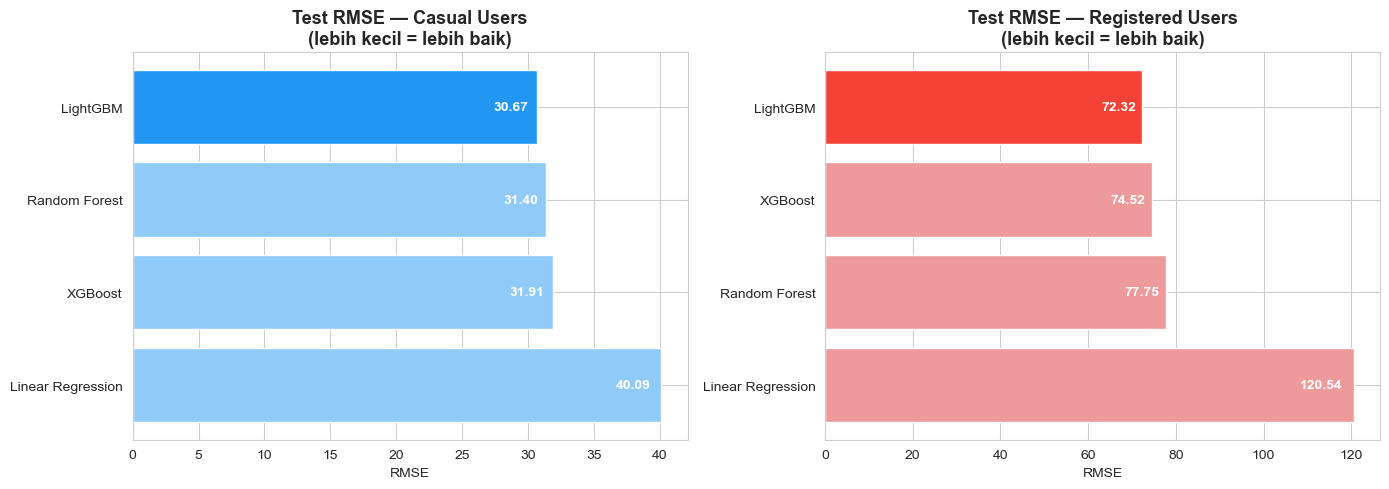

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Casual
colors_c = ['#2196F3' if i == 0 else '#90CAF9' for i in range(len(results_casual))]
axes[0].barh(results_casual['Model'], results_casual['Test RMSE'], color=colors_c, edgecolor='white')
axes[0].set_title('Test RMSE — Casual Users\n(lebih kecil = lebih baik)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis()
for i, v in enumerate(results_casual['Test RMSE']):
    axes[0].text(v * 0.98, i, f'{v:.2f}', va='center', ha='right', color='white', fontweight='bold')

# Registered
colors_r = ['#F44336' if i == 0 else '#EF9A9A' for i in range(len(results_registered))]
axes[1].barh(results_registered['Model'], results_registered['Test RMSE'], color=colors_r, edgecolor='white')
axes[1].set_title('Test RMSE — Registered Users\n(lebih kecil = lebih baik)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].invert_yaxis()
for i, v in enumerate(results_registered['Test RMSE']):
    axes[1].text(v * 0.98, i, f'{v:.2f}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Berdasarkan hasil perbandingan, **LightGBM** dan **XGBoost** secara konsisten memberikan RMSE terkecil dan R² tertinggi untuk kedua target. Kita akan melakukan hyperparameter tuning pada model **LightGBM** sebagai model terbaik.

## Hyperparameter Tuning

Kita akan melakukan hyperparameter tuning menggunakan **GridSearchCV** dengan 5-Fold Cross Validation pada model LightGBM untuk kedua target secara terpisah.

In [23]:
param_grid = {
    'model__n_estimators'  : [100, 200, 300],
    'model__max_depth'     : [5, 7, -1],
    'model__learning_rate' : [0.05, 0.1, 0.2],
    'model__num_leaves'    : [31, 63]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Parameter grid yang akan dicari:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")
print(f"\nTotal kombinasi: {3*3*3*2} kombinasi x 5 fold = {3*3*3*2*5} fits per target")

Parameter grid yang akan dicari:
  model__n_estimators: [100, 200, 300]
  model__max_depth: [5, 7, -1]
  model__learning_rate: [0.05, 0.1, 0.2]
  model__num_leaves: [31, 63]

Total kombinasi: 54 kombinasi x 5 fold = 270 fits per target


### Tuning Model — Target: Casual Users

In [24]:
pipe_casual = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(random_state=42, verbose=-1))
])

grid_casual = GridSearchCV(
    pipe_casual, param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_casual.fit(X_train, y_casual_train)

print("\nBest Params (Casual):")
for k, v in grid_casual.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE (Casual): {-grid_casual.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Params (Casual):
  model__learning_rate: 0.05
  model__max_depth: -1
  model__n_estimators: 100
  model__num_leaves: 31

Best CV RMSE (Casual): 30.7954


### Tuning Model — Target: Registered Users

In [25]:
pipe_registered = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(random_state=42, verbose=-1))
])

grid_registered = GridSearchCV(
    pipe_registered, param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_registered.fit(X_train, y_reg_train)

print("\nBest Params (Registered):")
for k, v in grid_registered.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE (Registered): {-grid_registered.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Params (Registered):
  model__learning_rate: 0.1
  model__max_depth: 7
  model__n_estimators: 100
  model__num_leaves: 31

Best CV RMSE (Registered): 74.5073


### Evaluasi Model Setelah Tuning

In [26]:
# Prediksi pada test set menggunakan model terbaik
y_casual_pred = np.maximum(grid_casual.best_estimator_.predict(X_test), 0)
y_reg_pred    = np.maximum(grid_registered.best_estimator_.predict(X_test), 0)

# Metrik Casual
casual_rmse = np.sqrt(mean_squared_error(y_casual_test, y_casual_pred))
casual_mae  = mean_absolute_error(y_casual_test, y_casual_pred)
casual_r2   = r2_score(y_casual_test, y_casual_pred)

# Metrik Registered
reg_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
reg_mae  = mean_absolute_error(y_reg_test, y_reg_pred)
reg_r2   = r2_score(y_reg_test, y_reg_pred)

# Tampilkan ringkasan
results_tuned = pd.DataFrame({
    'Target'   : ['Casual', 'Registered'],
    'RMSE'     : [round(casual_rmse, 3), round(reg_rmse, 3)],
    'MAE'      : [round(casual_mae, 3),  round(reg_mae, 3)],
    'R²'       : [round(casual_r2, 3),   round(reg_r2, 3)]
})

print("Performa Model LightGBM (Setelah Tuning) — Test Set:")
display(results_tuned)

Performa Model LightGBM (Setelah Tuning) — Test Set:


,Target,RMSE,MAE,R²
0,Casual,31.031,17.119,0.607
1,Registered,71.785,46.612,0.758


### Visualisasi Actual vs Predicted

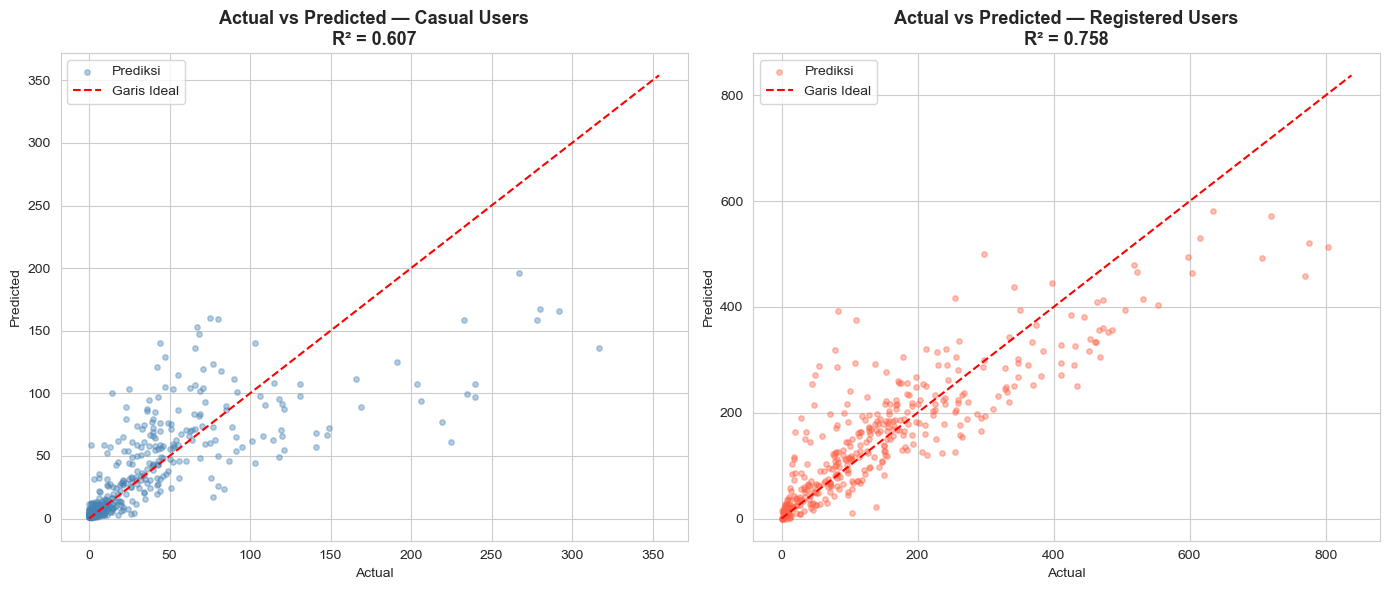

In [27]:
np.random.seed(42)
sample_idx = np.random.choice(len(y_casual_test), 400, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Casual
axes[0].scatter(y_casual_test.iloc[sample_idx], y_casual_pred[sample_idx],
                alpha=0.4, color='steelblue', s=15, label='Prediksi')
max_val = max(y_casual_test.max(), y_casual_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Garis Ideal')
axes[0].set_title(f'Actual vs Predicted — Casual Users\nR² = {casual_r2:.3f}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].legend()

# Registered
axes[1].scatter(y_reg_test.iloc[sample_idx], y_reg_pred[sample_idx],
                alpha=0.4, color='tomato', s=15, label='Prediksi')
max_val = max(y_reg_test.max(), y_reg_pred.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Garis Ideal')
axes[1].set_title(f'Actual vs Predicted — Registered Users\nR² = {reg_r2:.3f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

Titik-titik prediksi yang mendekati garis diagonal merah (garis ideal) menunjukkan bahwa model memiliki kemampuan prediksi yang baik. Model untuk `registered` cenderung lebih presisi dibanding `casual`, tercermin dari nilai R² yang lebih tinggi.

## Feature Importance

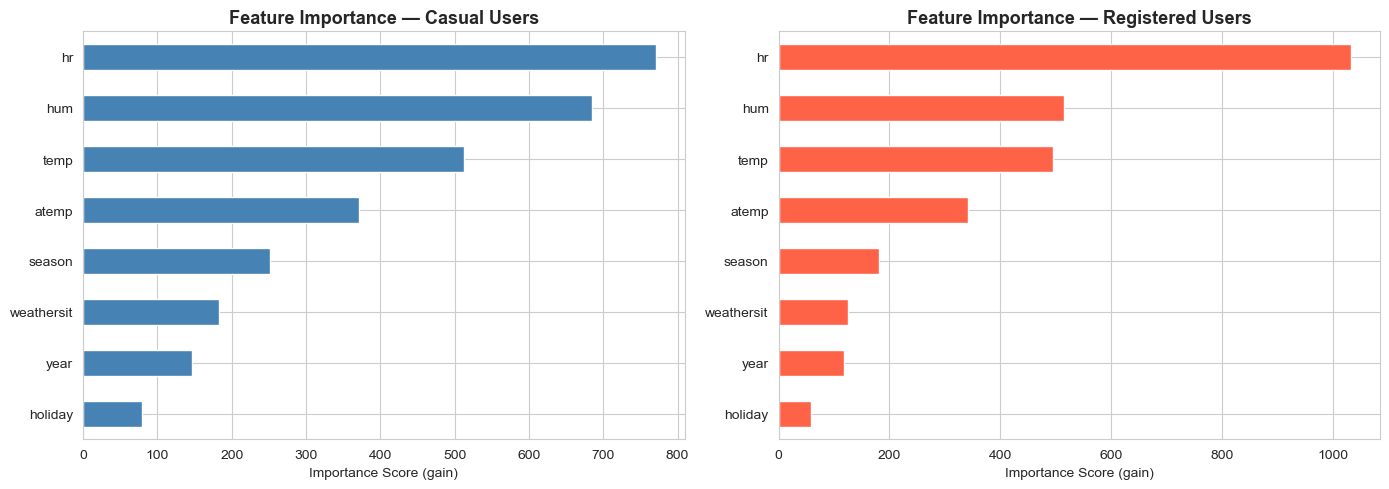

In [28]:
feature_names = numerical_features + passthrough_features

# Feature importance dari model terbaik (LightGBM after tuning)
best_casual_model = grid_casual.best_estimator_.named_steps['model']
fi_casual = pd.Series(best_casual_model.feature_importances_, index=feature_names).sort_values(ascending=True)

best_reg_model = grid_registered.best_estimator_.named_steps['model']
fi_registered = pd.Series(best_reg_model.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_casual.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Feature Importance — Casual Users', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score (gain)')

fi_registered.plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Feature Importance — Registered Users', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score (gain)')

plt.tight_layout()
plt.show()

**Interpretasi Feature Importance:**

- **Casual users**: fitur `hr` (jam) dan `temp` (suhu) paling dominan. Ini konsisten dengan temuan EDA — pengguna casual sangat dipengaruhi kondisi waktu rekreasi dan kenyamanan cuaca.

- **Registered users**: fitur `hr` (jam) mendominasi secara signifikan, mencerminkan pola komuter yang sangat teratur. Fitur `year` juga penting karena ada tren pertumbuhan yang jelas dari 2011 ke 2012.

- Fitur `holiday` dan `hum` memiliki kontribusi yang relatif kecil pada kedua model — meski tetap relevan, dampaknya tidak sebesar fitur temporal dan suhu.

## Conclusion & Recommendation

In [29]:
print("=" * 65)
print("  RINGKASAN PERFORMA MODEL AKHIR — LightGBM (Setelah Tuning)")
print("=" * 65)
print(f"  {'Target':<15} {'RMSE':<12} {'MAE':<12} {'R²':<10}")
print("-" * 55)
print(f"  {'Casual':<15} {casual_rmse:<12.3f} {casual_mae:<12.3f} {casual_r2:<10.3f}")
print(f"  {'Registered':<15} {reg_rmse:<12.3f} {reg_mae:<12.3f} {reg_r2:<10.3f}")
print("=" * 65)

  RINGKASAN PERFORMA MODEL AKHIR — LightGBM (Setelah Tuning)
  Target          RMSE         MAE          R²        
-------------------------------------------------------
  Casual          31.031       17.119       0.607     
  Registered      71.785       46.612       0.758     


**Kesimpulan:**

1. **Model LightGBM** terpilih sebagai model terbaik untuk memprediksi kedua target (casual dan registered), secara konsisten mengalahkan Linear Regression, Random Forest, dan XGBoost dalam hal RMSE dan R².

2. **Prediksi Registered users lebih akurat** dibanding Casual users. Hal ini masuk akal karena:
   - Registered users memiliki pola komuter yang **konsisten dan dapat diprediksi**
   - Casual users lebih dipengaruhi faktor situasional dan musiman yang lebih bervariasi

3. **Fitur jam (`hr`) adalah yang paling penting** untuk kedua model. Fitur suhu (`temp`) sangat penting untuk casual users, sementara fitur `year` (tren pertumbuhan) lebih penting untuk registered users.

4. **Implikasi Bisnis**: Dengan model ini, perusahaan bike sharing dapat:
   - Memprediksi permintaan per jam secara terpisah untuk dua segmen pengguna
   - Mengoptimalkan jadwal redistribusi sepeda antar stasiun
   - Menyesuaikan armada berdasarkan prediksi cuaca dan musim
   - Menjadwalkan maintenance sepeda pada jam-jam dengan permintaan rendah (dini hari)

   Sebagai contoh estimasi efisiensi: jika biaya redistribusi sepeda yang tidak perlu adalah Rp 50.000/unit/hari, dan model mengurangi over-redistribusi sebesar 20%, maka untuk armada 1.000 sepeda, penghematan yang dapat diraih mencapai **Rp 10.000.000/hari** atau ~**Rp 3,6 Miliar/tahun**.

#### Recommendation

Hal-hal yang bisa dilakukan untuk mengembangkan model lebih baik ke depannya:

1. **Tambahkan fitur hari dalam seminggu (weekday/weekend)**: Karena pola casual users sangat berbeda antara hari kerja dan akhir pekan, fitur ini berpotensi meningkatkan akurasi secara signifikan.

2. **Data lokasi stasiun**: Menambahkan fitur geografis seperti kepadatan penduduk, jarak ke pusat kota, atau ketersediaan transportasi umum di sekitar stasiun dapat membuat prediksi lebih granular dan actionable.

3. **Coba pendekatan Time Series**: Karena data ini memiliki komponen temporal yang kuat, pendekatan seperti SARIMA, Prophet, atau LSTM dapat dijajaki sebagai alternatif atau pelengkap model ML saat ini.

4. **Analisis residual lebih mendalam**: Identifikasi pola pada data yang masih salah tebak — terutama jam-jam ekstrem (sangat sepi atau sangat ramai) — untuk memahami limitasi model dan menentukan kapan model tidak boleh digunakan secara otomatis.

5. **Deploy sebagai REST API**: Model dapat di-deploy menggunakan FastAPI dan diintegrasikan ke sistem manajemen armada perusahaan untuk prediksi secara real-time.

# Thank You 🚲